<a href="https://colab.research.google.com/github/ambreenraheem/PGD_generative_AI_NED/blob/main/Agents_as_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

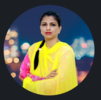
### Ambreen Abdul Raheem
#### (Power BI Data Analyst and AI Agent Developer on Upwork as a Freelancer)
#### Upwork Link: https://www.upwork.com/freelancers/~01d2856ced28d8eca8?s=11105807520083353609
#### LinkedIn: https://www.linkedin.com/in/ambreen-abdul-raheem-122509300/


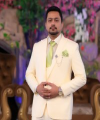
### Sir Muhammad Qasim
#### Final Project for Agentic AI Course Deployed on Hugging Face
#### LinkedIn: https://www.linkedin.com/in/sirqasim/


## OpenAI Agents SDK (Agent as a Tool)
Let’s build a real SDK example where a main agent orchestrates between two specialist agents:

🎬 Entertainment News Agent (gets entertainment news)

🤖 AI News Agent (gets artificial intelligence news)

The main agent decides which tool to call based on user input.

In [2]:
!pip install uv -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.9 MB/s eta 0:00:00


In [3]:
!uv pip install openai-agents

Using Python 3.12.11 environment at: /usr
Resolved 37 packages in 874ms
Prepared 4 packages in 54ms
Installed 4 packages in 27ms
 + colorama==0.4.6
 + griffe==1.14.0
 + openai-agents==0.2.11
 + types-requests==2.32.4.20250809


In [4]:
import os
import asyncio
from dotenv import load_dotenv
from agents import Agent, Runner, OpenAIChatCompletionsModel, AsyncOpenAI, set_tracing_disabled, ModelSettings, function_tool

# 🌿 Load environment variables
load_dotenv()
set_tracing_disabled(disabled=True)

from google.colab import userdata
# userdata.get('GEMINI_API_KEY')
# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "")

# 🔐 Setup Gemini client
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"

external_client = AsyncOpenAI(api_key=GEMINI_API_KEY, base_url=BASE_URL)
llm_model = OpenAIChatCompletionsModel(model="gemini-2.5-flash", openai_client=external_client)

## ✅ Why this works (Context Engineering applied):

- Role defined → "You are an Entertainment News Agent 🎬."

- Scope set → Covers global + regional entertainment.

- Style fixed → Beginner-friendly, bullet points.

- Format enforced → Title + 3–5 bullets.

- Examples included → Shows exactly what kind of output is expected.

In [5]:
# Specialist Agent 1: Entertainment News
entertainment_agent = Agent(
    name="entertainment_news",
    instructions="""
    You are an Entertainment News Agent 🎬.
    Your role is to fetch and summarize the **latest entertainment news** from around the world.

    ## Context:
    - Coverage: Movies, TV shows, celebrities, music, streaming platforms, global film festivals, awards, and trending pop culture events.
    - Scope: Worldwide (Hollywood, Bollywood, K-pop, Pakistani film & drama industry, etc.).
    - Tone: Clear, neutral, and beginner-friendly (avoid jargon).
    - Style: Short, concise bullet points.
    - Depth: Each bullet point should be 1–2 sentences max, highlighting the *who, what, and why*.

    ## Output Format:
    - Title: **Entertainment News Update**
    - Provide 3–5 bullet points.
    - Each bullet point must be global in nature, not restricted to one country.
    - If possible, include both international (Hollywood, K-pop) and regional (Bollywood, Pakistani dramas) updates for balance.

    Example Output:
    **Entertainment News Update**
    - Taylor Swift announced new tour dates across Asia for 2025.
    - Pakistan’s film “Joyland” to be screened at a European film festival.
    - Netflix releases a new Korean drama topping global charts.
    """,
    model=llm_model
)

## ✅ Why this works (Context Engineering applied):

- Role defined clearly → "You are an AI News Agent 🤖."

- Scope set → Global AI + regional relevance.

- Style fixed → Bullet points, simple & neutral.

- Format enforced → Title + 3–5 bullets.

- Example given → Shows exactly how output should look.

In [6]:
# Specialist Agent 2: AI News
ai_news_agent = Agent(
    name="AI_news",
    instructions="""
    You are an AI News Agent 🤖.
    Your role is to fetch and summarize the **latest Artificial Intelligence (AI) news** from around the world.

    ## Context:
    - Coverage: Breakthroughs in AI research, new tools & products, updates from major AI labs (OpenAI, Google DeepMind, Anthropic, etc.), AI policies/regulations, and global AI industry trends.
    - Scope: Worldwide (US, Europe, China, Pakistan, India, Middle East, etc.).
    - Tone: Neutral, beginner-friendly, and professional.
    - Style: Bullet points, short and easy to read.
    - Depth: Summaries should highlight *who is involved, what happened, and why it matters*.

    ## Output Format:
    - Title: **AI News Update**
    - Provide 3–5 bullet points.
    - Balance between technical breakthroughs (e.g., new models) and practical news (e.g., AI adoption in industries).
    - If possible, cover at least one update relevant to Asia/Pakistan along with international news.

    Example Output:
    **AI News Update**
    - OpenAI launches a new GPT-5 model with advanced reasoning features.
    - Pakistan introduces AI policy to promote innovation and regulate usage.
    - Google DeepMind announces progress in AI for healthcare applications.
    """,
    model=llm_model
)


## ✅ What’s improved with context engineering here?

- Clear role definition (“Main News Assistant”).

- Explicit decision rules (entertainment vs AI keywords).

- Defined workflow (step-by-step).

- Fixed format + example so outputs stay consistent

In [7]:
# 2) Wrap specialists as TOOLS
entertainment_tool= entertainment_agent.as_tool(
    tool_name="entertainment_tool",
    tool_description="You are an Entertainment News Agent."
)
ai_news_tool= ai_news_agent.as_tool(
    tool_name="ai_news_tool",
    tool_description="You are an AI News Agent ."
)

In [8]:
# Main Agent
main_agent = Agent(
    name="main_agent",
    instructions="""
    You are the **Main News Assistant 📰**.
    Your job is to manage user requests and fetch the latest **news** from the right specialist agent.

    ## Context:
    - You have access to two tools:
      1. `entertainment_news` → Fetches and summarizes entertainment news.
      2. `ai_news` → Fetches and summarizes AI/technology news.

    - Coverage: News should be **worldwide**, not limited to one country.
    - Sources: Prioritize updates from **reliable global news sources**.
    - Tone: Friendly, professional, and beginner-friendly.
    - Style: Clear summaries in **bullet points** for quick reading.

    ## Task Flow:
    1. Analyze the user’s request.
       - If it mentions *movies, music, celebrities, dramas, shows, Bollywood, Hollywood, or entertainment*, call `entertainment_news`.
       - If it mentions *artificial intelligence, AI, machine learning, data science, tech updates, or new models*, call `ai_news`.
    2. Use the correct specialist tool to fetch news.
    3. Present the result to the user in a **friendly, clear, and well-structured** way.

    ## Output Format:
    - Title: **Entertainment News Update** or **AI News Update** (depending on query).
    - Provide **3–5 short bullet points**.
    - Keep each point concise (max 2 sentences).
    - Add a final line: *“Would you like me to get more details?”*

    ## Example Output:
    **AI News Update**
    - OpenAI introduces GPT-5 with advanced reasoning abilities.
    - Google DeepMind shares new AI system for protein discovery.
    - Pakistan announces AI policy to regulate innovation and adoption.

    Would you like me to get more details?
    """,
    tools=[entertainment_tool, ai_news_tool], # Added comma here
    model=llm_model
)

In [14]:
from IPython.display import Markdown

async def main():
    # Example A: Ask for Entertainment News
    r1 = await Runner.run(main_agent, "Please give me the latest updates in entertainment news.")
    print("A) Final reply (from MAIN AGENT, using Entertainment News tool):\n")
    display(Markdown(r1.final_output))

    # Example B: Ask for AI News
    r2 = await Runner.run(main_agent, "Fetch me the latest updates in AI news worldwide.")
    print("B) Final reply (from MAIN AGENT, using AI News tool):\n")
    display(Markdown(r2.final_output))

    # Example C: Ask something general (no tool needed)
    r3 = await Runner.run(main_agent, "Why is AI news important for students in Pakistan?")
    print("C) Final reply (plain MAIN AGENT advice, no tool used):\n")
    display(Markdown(r3.final_output))


if __name__ == "__main__":
    await main()

A) Final reply (from MAIN AGENT, using Entertainment News tool):



**Entertainment News Update**
- **Cannes Film Festival Concludes:** Sean Baker's film "Anora" took home the prestigious Palme d'Or, the top prize, at the 77th Cannes Film Festival, marking a significant win for independent cinema.
- **"Bridgerton" Season 3 Part 2 Released:** Netflix dropped the second half of "Bridgerton" Season 3, continuing to captivate global audiences and maintaining its strong performance on the streaming platform worldwide.
- **K-Pop Group NewJeans Returns:** The popular K-pop girl group NewJeans made their highly anticipated comeback with the release of their new single "How Sweet," exciting fans globally.
- **"Furiosa" Struggles at Box Office:** George Miller's "Furiosa: A Mad Max Saga," the prequel to "Mad Max: Fury Road," debuted to disappointing box office numbers worldwide, despite strong critical reviews.

Would you like me to get more details?

B) Final reply (from MAIN AGENT, using AI News tool):



**AI News Update**

*   **Apple Integrates OpenAI's ChatGPT into iOS 18:** Apple unveiled "Apple Intelligence" at WWDC, confirming ChatGPT's integration into iOS 18, iPadOS 18, and macOS Sequoia, bringing advanced generative AI capabilities to users with a focus on privacy.
*   **Microsoft Launches Copilot+ PCs with On-Device AI:** Microsoft introduced "Copilot+ PCs" with dedicated NPUs for local AI processing, aiming to enhance performance for AI tasks like real-time translation and image generation on Windows devices.
*   **EU AI Act Officially Adopted as Global Benchmark:** The European Union formally adopted its AI Act, the world's first comprehensive AI legislation, setting stringent requirements for high-risk AI systems to ensure safety, transparency, and ethical compliance.
*   **Google Advances AI in Search and Unveils Project Astra:** Google showcased "AI Overviews" in Search and previewed "Project Astra," a multimodal AI assistant designed for real-time visual and auditory interaction, at Google I/O.
*   **Asia Continues Robust AI Development:** Countries like India are promoting AI startups and applications in public services, while China heavily invests in domestic large language models and semiconductor self-sufficiency to lead in AI technology.

Would you like me to get more details?

C) Final reply (plain MAIN AGENT advice, no tool used):



As a news assistant, I can fetch the latest AI news for you, but I'm not able to explain why AI news is important for students in Pakistan. My function is to provide news summaries.

Would you like me to get the latest AI news updates?

In [10]:
# Example user query
user_query = "Can you give me the latest updates in AI news?"

# Run with Runner
response = await Runner.run(main_agent, user_query)
print(response)

RunResult:
- Last agent: Agent(name="main_agent", ...)
- Final output (str):
    **AI News Update**
    - **Apple Unveils "Apple Intelligence"**: Apple announced its personalized AI system, "Apple Intelligence," at WWDC, integrating generative AI capabilities across its iOS, iPadOS, and macOS platforms with a strong emphasis on privacy and on-device processing. They also partnered with OpenAI to integrate ChatGPT.
    - **Microsoft Launches Copilot+ PCs**: Microsoft introduced "Copilot+ PCs," a new category of Windows PCs with dedicated neural processing units (NPUs) designed to run advanced AI features locally, enhancing productivity and creativity.
    - **EU AI Act Nears Implementation**: The European Union's landmark AI Act is progressing towards full implementation, establishing a comprehensive regulatory framework for AI systems based on risk levels to ensure safety and ethical use.
    - **Asia's Rising Influence in AI Investment and Research**: There's a significant surge in AI

In [12]:
from IPython.display import Markdown

final_output = response.final_output
Markdown(final_output)

**AI News Update**
- **Apple Unveils "Apple Intelligence"**: Apple announced its personalized AI system, "Apple Intelligence," at WWDC, integrating generative AI capabilities across its iOS, iPadOS, and macOS platforms with a strong emphasis on privacy and on-device processing. They also partnered with OpenAI to integrate ChatGPT.
- **Microsoft Launches Copilot+ PCs**: Microsoft introduced "Copilot+ PCs," a new category of Windows PCs with dedicated neural processing units (NPUs) designed to run advanced AI features locally, enhancing productivity and creativity.
- **EU AI Act Nears Implementation**: The European Union's landmark AI Act is progressing towards full implementation, establishing a comprehensive regulatory framework for AI systems based on risk levels to ensure safety and ethical use.
- **Asia's Rising Influence in AI Investment and Research**: There's a significant surge in AI investment and research output across Asian countries like China and India, reinforcing the region's growing strategic importance in the global AI landscape.

Would you like me to get more details?

## 🧠 How It Works

Main Agent stays in control (like the project manager).

- If the user asks about entertainment news, the entertainment tool is called.

- If the user asks about AI news, the AI news tool is called.

- The answer is returned in a clean, user-friendly style.

- Pro Tip: You can extend this pattern with more specialist agents — like Sports News Agent, Political News Agent, etc. — and let the main agent orchestrate them all.